<a href="https://colab.research.google.com/github/Arminius1204/Machine-Learning-Algorithms-Parkinson-s-Dataset/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 2

### 1. Data Loading and Initial Inspection

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

parkinsons = fetch_ucirepo(id=174)

X = parkinsons.data.features
y = parkinsons.data.targets

# Rename columns to ensure uniqueness, as some names might be duplicated after fetching
# based on the original dataset's naming conventions (e.g., Jitter(%), Jitter(Abs))
new_column_names = list(X.columns)

# Assuming order based on common Parkinson's dataset feature lists
# MDVP:Jitter (index 3) is likely Jitter(%) -> MDVP:Jitter_percent
# MDVP:Jitter (index 4) is likely Jitter(Abs) -> MDVP:Jitter_Abs
# MDVP:Shimmer (index 8) is likely Shimmer -> MDVP:Shimmer_local
# MDVP:Shimmer (index 9) is likely Shimmer(dB) -> MDVP:Shimmer_dB

new_column_names[3] = 'MDVP:Jitter_percent'
new_column_names[4] = 'MDVP:Jitter_Abs'
new_column_names[8] = 'MDVP:Shimmer_local'
new_column_names[9] = 'MDVP:Shimmer_dB'

X.columns = new_column_names

print("Features (X) before any transformations:")
display(X.head())
print("\nTarget (y):")
display(y.head())

Features (X) before any transformations:


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter_percent,MDVP:Jitter_Abs,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer_local,MDVP:Shimmer_dB,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00784,0.00370,0.00554,0.01109,0.04374,0.04374,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00968,0.00465,0.00696,0.01394,0.06134,0.06134,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.01050,0.00544,0.00781,0.01633,0.05233,0.05233,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00997,0.00502,0.00698,0.01505,0.05492,0.05492,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.01284,0.00655,0.00908,0.01966,0.06425,0.06425,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335



Target (y):


,status
0,1
1,1
2,1
3,1
4,1


### 2. Feature Engineering

In [ ]:
X_engineered = X.copy()

X_engineered['MDVP:Fo_sq'] = X_engineered['MDVP:Fo']**2

X_engineered['Jitter_Shimmer_Interaction'] = X_engineered['MDVP:Jitter_percent'] * X_engineered['MDVP:Shimmer_local']

X_engineered['Fhi_Flo_Ratio'] = X_engineered['MDVP:Fhi'] / (X_engineered['MDVP:Flo'] + 1e-6)

print("Features (X) after applying feature engineering:")
display(X_engineered.head())

Features (X) after applying feature engineering:


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter_percent,MDVP:Jitter_Abs,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer_local,MDVP:Shimmer_dB,...,HNR,RPDE,DFA,spread1,spread2,D2,PPE,MDVP:Fo_sq,Jitter_Shimmer_Interaction,Fhi_Flo_Ratio
0,119.992,157.302,74.997,0.00784,0.00784,0.00370,0.00554,0.01109,0.04374,0.04374,...,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,14398.080064,0.000343,2.097444
1,122.400,148.650,113.819,0.00968,0.00968,0.00465,0.00696,0.01394,0.06134,0.06134,...,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,14981.760000,0.000594,1.306021
2,116.682,131.111,111.555,0.01050,0.01050,0.00544,0.00781,0.01633,0.05233,0.05233,...,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,13614.689124,0.000549,1.175304
3,116.676,137.871,111.366,0.00997,0.00997,0.00502,0.00698,0.01505,0.05492,0.05492,...,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,13613.288976,0.000548,1.237999
4,116.014,141.781,110.655,0.01284,0.01284,0.00655,0.00908,0.01966,0.06425,0.06425,...,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,13459.248196,0.000825,1.281289


### 3. Feature Selection

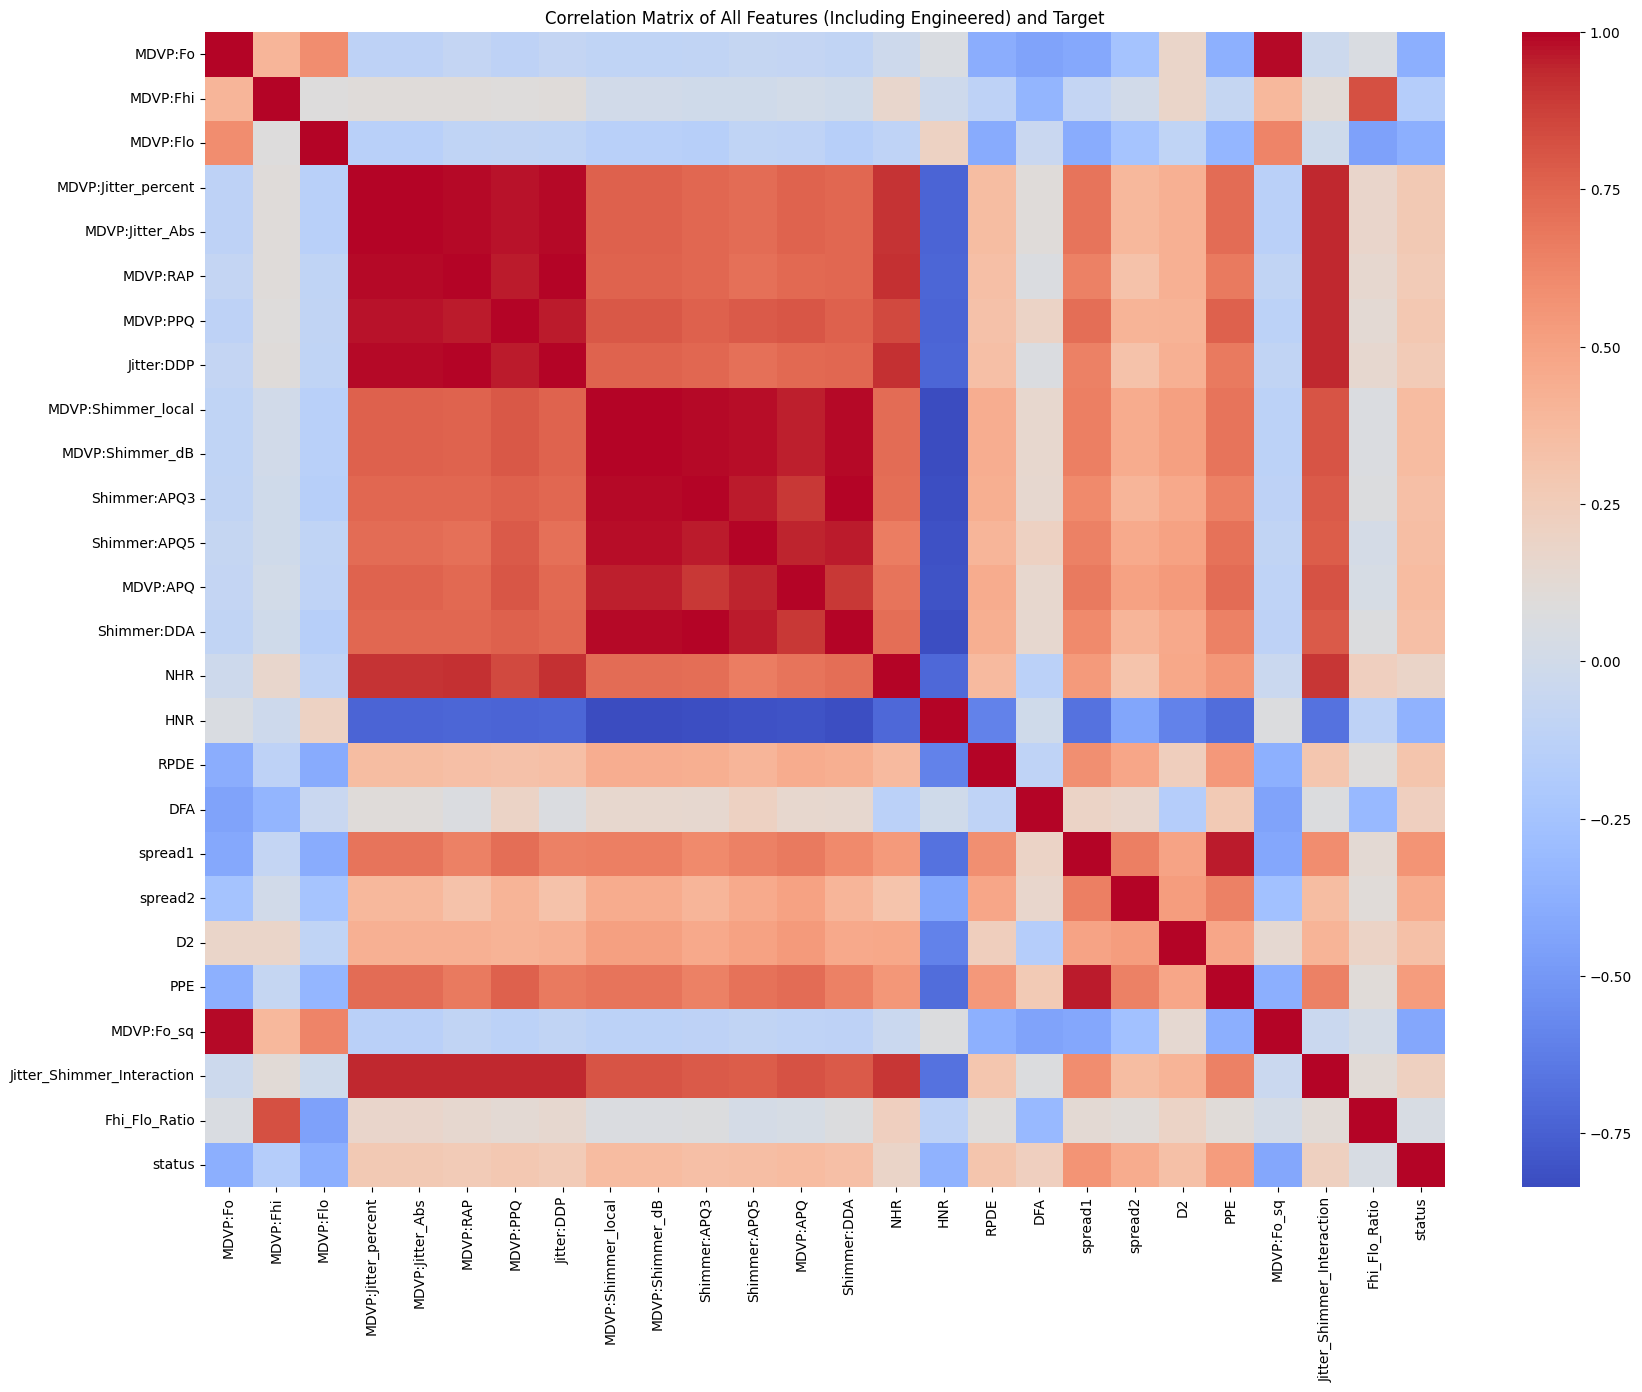

Features to drop based on high correlation (threshold > 0.9):
['MDVP:Jitter_Abs', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer_dB', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'PPE', 'MDVP:Fo_sq', 'Jitter_Shimmer_Interaction']

Features after correlation-based selection:


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter_percent,MDVP:Shimmer_local,HNR,RPDE,DFA,spread1,spread2,D2,Fhi_Flo_Ratio
0,119.992,157.302,74.997,0.00784,0.04374,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,2.097444
1,122.400,148.650,113.819,0.00968,0.06134,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,1.306021
2,116.682,131.111,111.555,0.01050,0.05233,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,1.175304
3,116.676,137.871,111.366,0.00997,0.05492,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,1.237999
4,116.014,141.781,110.655,0.01284,0.06425,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,1.281289


Number of features retained: 12
Justification: Highly correlated features (e.g., Jitter:DDP and MDVP:Jitter(%) often measure similar aspects of vocal tremor. Removing one helps reduce multicollinearity and improve model interpretability without losing much information.

Features after SelectKBest selection:


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=15 is greater than n_features=12. All the features will be returned.
  warnings.warn(


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter_percent,MDVP:Shimmer_local,HNR,RPDE,DFA,spread1,spread2,D2,Fhi_Flo_Ratio
0,119.992,157.302,74.997,0.00784,0.04374,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,2.097444
1,122.400,148.650,113.819,0.00968,0.06134,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,1.306021
2,116.682,131.111,111.555,0.01050,0.05233,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,1.175304
3,116.676,137.871,111.366,0.00997,0.05492,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,1.237999
4,116.014,141.781,110.655,0.01284,0.06425,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,1.281289


Number of features retained: 12
Justification: SelectKBest (with f_classif) helps in retaining features that have the strongest statistical relationship with the target variable, indicating their importance for classification. The top 15 features were chosen based on their individual predictive power.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np

df_combined = pd.concat([X_engineered, y], axis=1)

plt.figure(figsize=(20, 15))
sns.heatmap(df_combined.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of All Features (Including Engineered) and Target')
plt.show()

correlation_matrix = X_engineered.corr().abs()
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

print("Features to drop based on high correlation (threshold > 0.9):")
print(to_drop_corr)

X_selected_corr = X_engineered.drop(columns=to_drop_corr)
print("\nFeatures after correlation-based selection:")
display(X_selected_corr.head())
print(f"Number of features retained: {X_selected_corr.shape[1]}")
print("Justification: Highly correlated features (e.g., Jitter:DDP and MDVP:Jitter(%) often measure similar aspects of vocal tremor. Removing one helps reduce multicollinearity and improve model interpretability without losing much information.")

k_best_selector = SelectKBest(score_func=f_classif, k=15)
X_selected_kbest = k_best_selector.fit_transform(X_selected_corr, y.values.ravel())

selected_features_mask = k_best_selector.get_support()
selected_feature_names = X_selected_corr.columns[selected_features_mask]

X_final_selected = pd.DataFrame(X_selected_kbest, columns=selected_feature_names, index=X_selected_corr.index)
print("\nFeatures after SelectKBest selection:")
display(X_final_selected.head())
print(f"Number of features retained: {X_final_selected.shape[1]}")
print("Justification: SelectKBest (with f_classif) helps in retaining features that have the strongest statistical relationship with the target variable, indicating their importance for classification. The top 15 features were chosen based on their individual predictive power.")

### 4. Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Load dataset
parkinsons = fetch_ucirepo(id=174)

X = parkinsons.data.features
y = parkinsons.data.targets

# -------------------------------
# Standard Scaling
# -------------------------------

scaler_standard = StandardScaler()

X_scaled_standard = scaler_standard.fit_transform(X)

X_scaled_standard_df = pd.DataFrame(
    X_scaled_standard,
    columns=X.columns,
    index=X.index
)

print("Features after StandardScaler:")
display(X_scaled_standard_df.head())

print("Justification: StandardScaler transforms features to have zero mean and unit variance. This is useful for machine learning algorithms such as SVM and Logistic Regression because it prevents features with larger numerical ranges from dominating the model.")


# -------------------------------
# Min-Max Scaling
# -------------------------------

scaler_minmax = MinMaxScaler()

X_scaled_minmax = scaler_minmax.fit_transform(X)

X_scaled_minmax_df = pd.DataFrame(
    X_scaled_minmax,
    columns=X.columns,
    index=X.index
)

print("\nFeatures after MinMaxScaler:")
display(X_scaled_minmax_df.head())

print("Justification: MinMaxScaler scales features to a fixed range, usually 0 to 1. This is useful for algorithms such as neural networks and keeps all features within a common numerical range.")

Features after StandardScaler:


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,-0.829300,-0.436165,-0.952037,0.334914,0.334914,0.132963,0.760800,0.131755,0.745985,0.745985,...,0.332985,0.607532,-0.067893,-0.193225,-0.807838,1.760814,0.801323,0.480477,-0.210531,0.868886
1,-0.770972,-0.530974,-0.057721,0.715418,0.715418,0.453892,1.276809,0.452684,1.681731,1.681731,...,1.159454,1.548254,-0.137843,-0.634508,-0.387524,1.837562,1.479853,1.311185,0.275077,1.803605
2,-0.909476,-0.723168,-0.109875,0.884991,0.884991,0.720770,1.585687,0.721813,1.202693,1.202693,...,0.699187,1.175323,-0.291633,-0.279760,-0.662075,1.942048,1.141445,1.017682,-0.103629,1.402661
3,-0.909622,-0.649092,-0.114229,0.775389,0.775389,0.578885,1.284076,0.577677,1.340396,1.340396,...,0.806859,1.340229,-0.280719,-0.281346,-0.613134,1.832380,1.440945,1.293840,0.062145,1.806954
4,-0.925657,-0.606245,-0.130608,1.368893,1.368893,1.095750,2.047187,1.096793,1.836448,1.836448,...,1.216839,1.899461,-0.178026,-0.506745,-0.783021,1.909364,1.780940,0.096195,-0.130026,2.267082


Justification: StandardScaler transforms features to have zero mean and unit variance. This is useful for machine learning algorithms such as SVM and Logistic Regression because it prevents features with larger numerical ranges from dominating the model.

Features after MinMaxScaler:


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,0.184308,0.112592,0.054815,0.195680,0.195680,0.145472,0.247588,0.145288,0.312215,0.312215,...,0.172448,0.332584,0.068307,0.511745,0.369155,0.960148,0.569875,0.585765,0.390661,0.497310
1,0.198327,0.094930,0.278323,0.254130,0.254130,0.191233,0.323687,0.191042,0.472887,0.472887,...,0.279424,0.516048,0.059331,0.432577,0.470830,0.977024,0.703277,0.741337,0.473145,0.671326
2,0.165039,0.059128,0.265288,0.280178,0.280178,0.229287,0.369239,0.229411,0.390634,0.390634,...,0.219848,0.443317,0.039596,0.496220,0.404416,1.000000,0.636745,0.686371,0.408819,0.596682
3,0.165004,0.072927,0.264200,0.263342,0.263342,0.209056,0.324759,0.208862,0.414278,0.414278,...,0.233785,0.475478,0.040997,0.495936,0.416255,0.975885,0.695627,0.738089,0.436977,0.671949
4,0.161150,0.080909,0.260107,0.354511,0.354511,0.282755,0.437299,0.282870,0.499452,0.499452,...,0.286852,0.584542,0.054174,0.455499,0.375159,0.992813,0.762472,0.513798,0.404336,0.757611


Justification: MinMaxScaler scales features to a fixed range, usually 0 to 1. This is useful for algorithms such as neural networks and keeps all features within a common numerical range.


**Lab 4**

### Model Training and Evaluation

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming X_scaled_standard_df is the final processed feature set
# and y is the target variable (parkinsons.data.targets)

X_train, X_test, y_train, y_test = train_test_split(X_scaled_standard_df, y.values.ravel(), test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (156, 22)
Shape of X_test: (39, 22)
Shape of y_train: (156,)
Shape of y_test: (39,)


#### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Sensitivity (True Positive Rate) and Specificity (True Negative Rate)
# Assuming binary classification where 1 is the positive class
tn, fp, fn, tp = conf_matrix_log_reg.ravel()
sensitivity_log_reg = tp / (tp + fn)
specificity_log_reg = tn / (tn + fp)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"Sensitivity: {sensitivity_log_reg:.4f}")
print(f"Specificity: {specificity_log_reg:.4f}")
print("Confusion Matrix:\n", conf_matrix_log_reg)

Logistic Regression Performance:
Accuracy: 0.8974
Precision: 0.8889
Recall: 1.0000
F1-Score: 0.9412
Sensitivity: 1.0000
Specificity: 0.4286
Confusion Matrix:
 [[ 3  4]
 [ 0 32]]


#### Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

# Initialize and train the SVM model
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

tn, fp, fn, tp = conf_matrix_svm.ravel()
sensitivity_svm = tp / (tp + fn)
specificity_svm = tn / (tn + fp)

print("Support Vector Machine Performance:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print(f"Sensitivity: {sensitivity_svm:.4f}")
print(f"Specificity: {specificity_svm:.4f}")
print("Confusion Matrix:\n", conf_matrix_svm)

Support Vector Machine Performance:
Accuracy: 0.8974
Precision: 0.8889
Recall: 1.0000
F1-Score: 0.9412
Sensitivity: 1.0000
Specificity: 0.4286
Confusion Matrix:
 [[ 3  4]
 [ 0 32]]


#### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

tn, fp, fn, tp = conf_matrix_dt.ravel()
sensitivity_dt = tp / (tp + fn)
specificity_dt = tn / (tn + fp)

print("Decision Tree Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"Sensitivity: {sensitivity_dt:.4f}")
print(f"Specificity: {specificity_dt:.4f}")
print("Confusion Matrix:\n", conf_matrix_dt)

Decision Tree Performance:
Accuracy: 0.9231
Precision: 0.9394
Recall: 0.9688
F1-Score: 0.9538
Sensitivity: 0.9688
Specificity: 0.7143
Confusion Matrix:
 [[ 5  2]
 [ 1 31]]


#### 5.4 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

tn, fp, fn, tp = conf_matrix_rf.ravel()
sensitivity_rf = tp / (tp + fn)
specificity_rf = tn / (tn + fp)

print("Random Forest Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"Sensitivity: {sensitivity_rf:.4f}")
print(f"Specificity: {specificity_rf:.4f}")
print("Confusion Matrix:\n", conf_matrix_rf)

Random Forest Performance:
Accuracy: 0.9487
Precision: 0.9412
Recall: 1.0000
F1-Score: 0.9697
Sensitivity: 1.0000
Specificity: 0.7143
Confusion Matrix:
 [[ 5  2]
 [ 0 32]]


## Comparison of Models

In [ ]:
import pandas as pd

# Create a dictionary to store results
results = {
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_log_reg, accuracy_svm, accuracy_dt, accuracy_rf],
    'Precision': [precision_log_reg, precision_svm, precision_dt, precision_rf],
    'Recall': [recall_log_reg, recall_svm, recall_dt, recall_rf],
    'F1-Score': [f1_log_reg, f1_svm, f1_dt, f1_rf],
    'Sensitivity': [sensitivity_log_reg, sensitivity_svm, sensitivity_dt, sensitivity_rf],
    'Specificity': [specificity_log_reg, specificity_svm, specificity_dt, specificity_rf]
}

results_df = pd.DataFrame(results)

print("Comparison of Classification Models:")
display(results_df.sort_values(by='Accuracy', ascending=False))

Comparison of Classification Models:


,Model,Accuracy,Precision,Recall,F1-Score,Sensitivity,Specificity
3,Random Forest,0.948718,0.941176,1.00000,0.969697,1.00000,0.714286
2,Decision Tree,0.923077,0.939394,0.96875,0.953846,0.96875,0.714286
1,SVM,0.897436,0.888889,1.00000,0.941176,1.00000,0.428571
0,Logistic Regression,0.897436,0.888889,1.00000,0.941176,1.00000,0.428571


/tmp/ipykernel_1485/1566758537.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1485/1566758537.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1485/1566758537.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1485/1566758537.py:12: FutureWarning: 

Passing `palette` without assigni

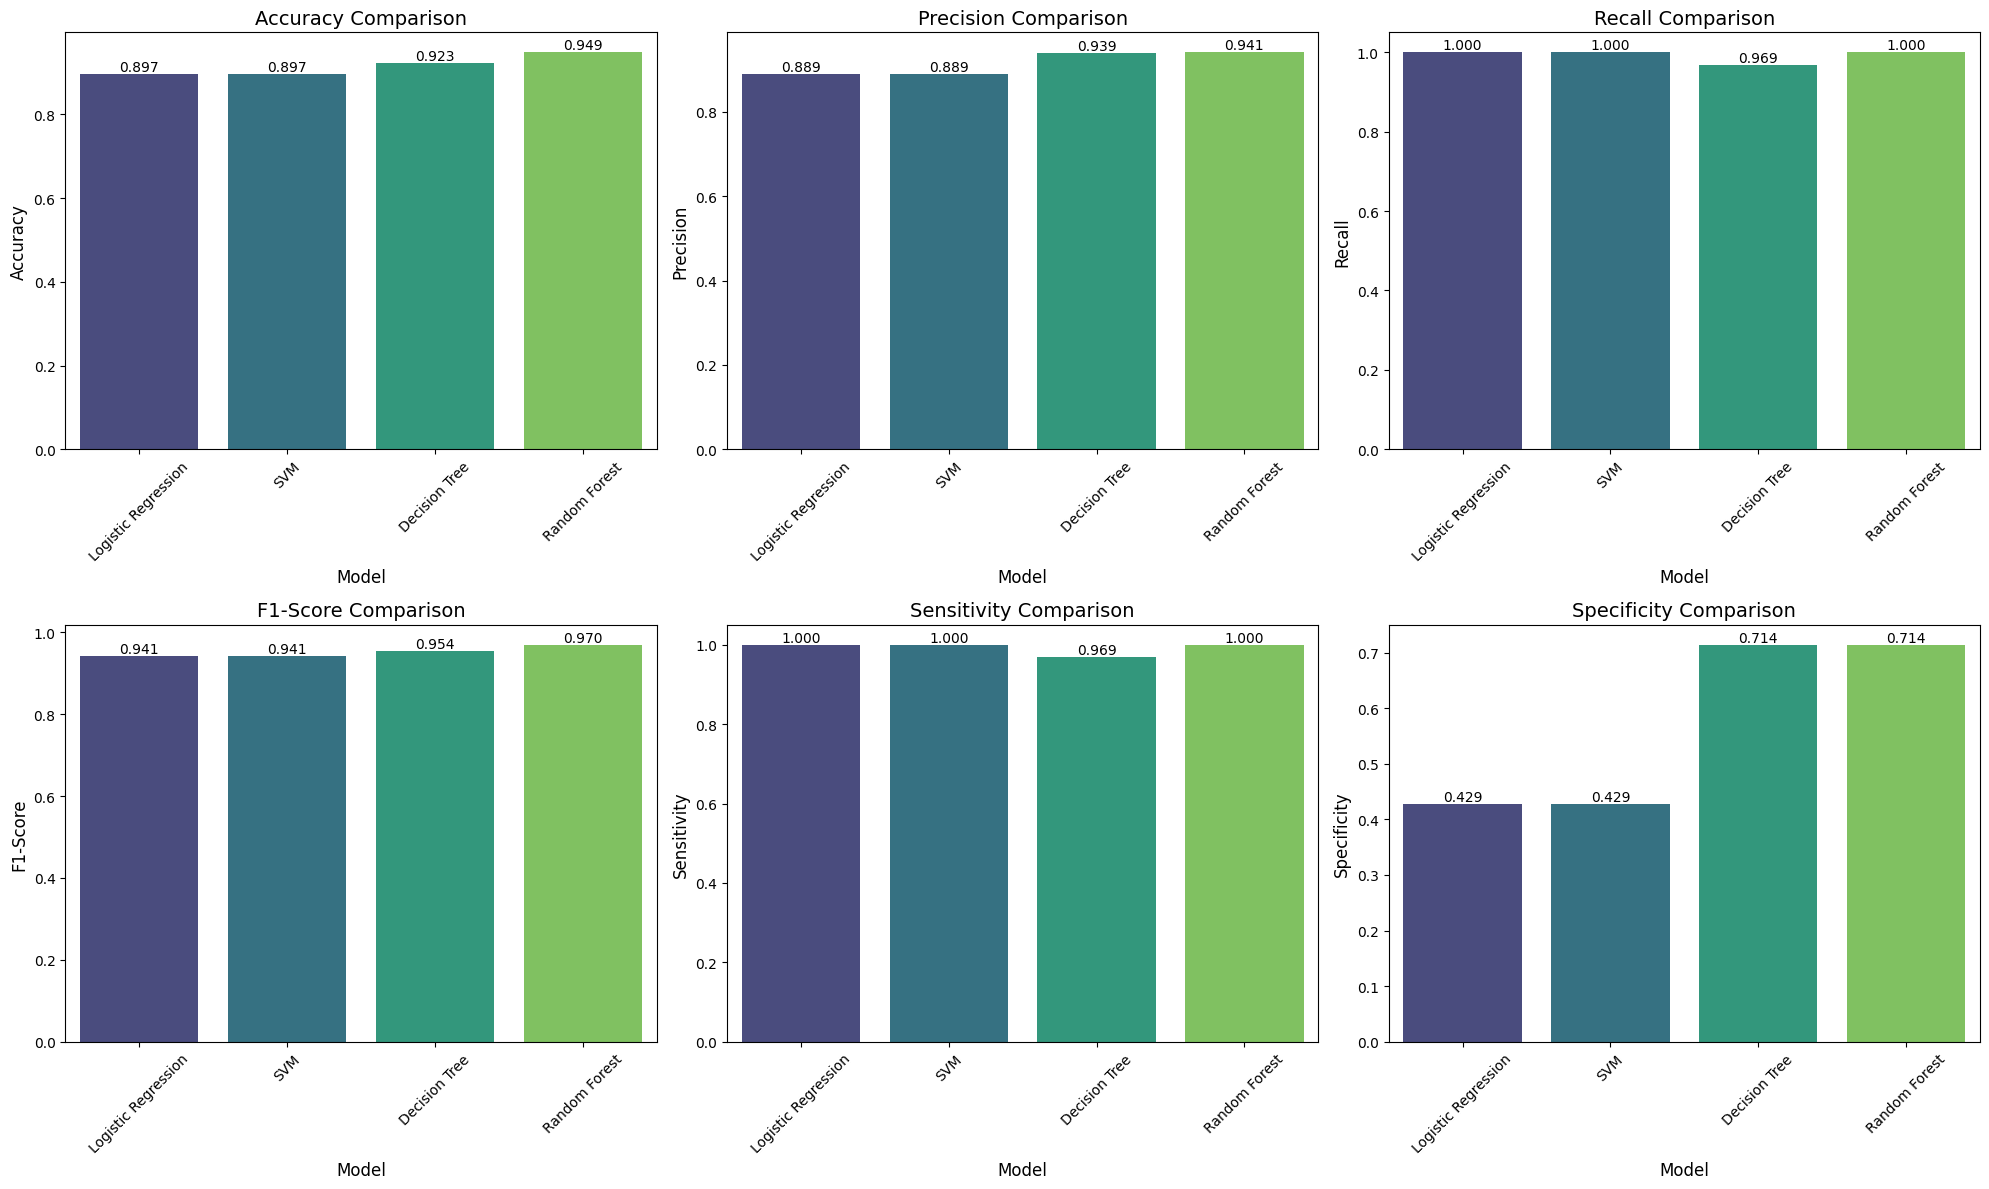

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Sensitivity', 'Specificity']
models = results_df['Model'].values

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
axes = axes.flatten() # Flatten the 2x3 grid into a 1D array for easy iteration

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=results_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison', fontsize=14)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

    # Annotate bars with values
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f', fontsize=10)

plt.tight_layout()
plt.show()

## Lab 3

### Linear Regression: Predicting

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Define target and features for Linear Regression
X_lr = X_scaled_standard_df.drop(columns=['MDVP:Fo'])
y_lr = X_scaled_standard_df['MDVP:Fo']

# Split data into training and testing sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_lr, y_train_lr)

# Make predictions
y_pred_lr = linear_model.predict(X_test_lr)

# Evaluate the model
mse = mean_squared_error(y_test_lr, y_pred_lr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_lr, y_pred_lr)

print("Linear Regression Performance (Predicting 'MDVP:Fo'):")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Linear Regression Performance (Predicting 'MDVP:Fo'):
Mean Squared Error (MSE): 0.2258
Root Mean Squared Error (RMSE): 0.4752
Mean Absolute Error (MAE): 0.3785


## Lab 5

Dataset shape: (195, 22)


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00784,0.00370,0.00554,0.01109,0.04374,0.04374,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00968,0.00465,0.00696,0.01394,0.06134,0.06134,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.01050,0.00544,0.00781,0.01633,0.05233,0.05233,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00997,0.00502,0.00698,0.01505,0.05492,0.05492,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.01284,0.00655,0.00908,0.01966,0.06425,0.06425,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335



Features after Standard Scaling:


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,-0.829300,-0.436165,-0.952037,0.334914,0.334914,0.132963,0.760800,0.131755,0.745985,0.745985,...,0.332985,0.607532,-0.067893,-0.193225,-0.807838,1.760814,0.801323,0.480477,-0.210531,0.868886
1,-0.770972,-0.530974,-0.057721,0.715418,0.715418,0.453892,1.276809,0.452684,1.681731,1.681731,...,1.159454,1.548254,-0.137843,-0.634508,-0.387524,1.837562,1.479853,1.311185,0.275077,1.803605
2,-0.909476,-0.723168,-0.109875,0.884991,0.884991,0.720770,1.585687,0.721813,1.202693,1.202693,...,0.699187,1.175323,-0.291633,-0.279760,-0.662075,1.942048,1.141445,1.017682,-0.103629,1.402661
3,-0.909622,-0.649092,-0.114229,0.775389,0.775389,0.578885,1.284076,0.577677,1.340396,1.340396,...,0.806859,1.340229,-0.280719,-0.281346,-0.613134,1.832380,1.440945,1.293840,0.062145,1.806954
4,-0.925657,-0.606245,-0.130608,1.368893,1.368893,1.095750,2.047187,1.096793,1.836448,1.836448,...,1.216839,1.899461,-0.178026,-0.506745,-0.783021,1.909364,1.780940,0.096195,-0.130026,2.267082


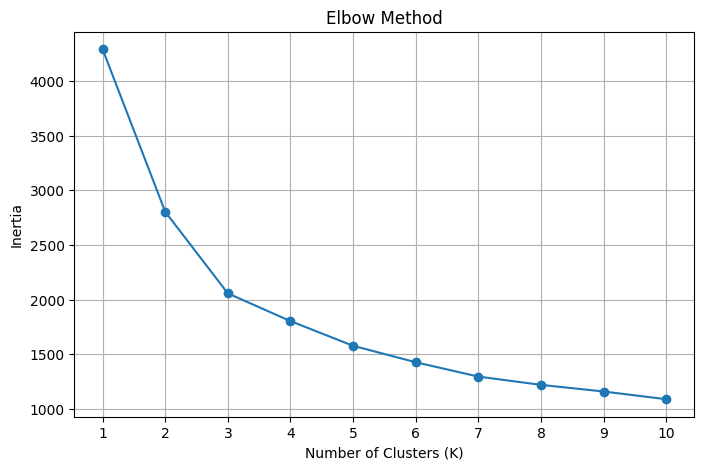


Cluster labels:


,Cluster
0,0
1,0
2,0
3,0
4,0
5,0
6,1
7,1
8,0
9,0



Number of data points in each cluster:
Cluster
0     77
1    106
2     12
Name: count, dtype: int64

Cluster Centroids:


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
Cluster,,,,,,,,,,,,,,,,,,,,,
0,135.524766,163.970026,94.936805,0.007045,0.007045,0.003713,0.003986,0.011139,0.039505,0.039505,...,0.031113,0.063435,0.027473,19.327727,0.568655,0.732230,-5.094898,0.253652,2.449171,0.253214
1,166.785019,215.052962,129.865689,0.003901,0.003901,0.001947,0.002093,0.005841,0.017342,0.017342,...,0.013879,0.027168,0.009222,24.803509,0.438806,0.707515,-6.341231,0.195621,2.264031,0.152846
2,163.330500,251.179417,133.950500,0.021417,0.021417,0.012708,0.011944,0.038123,0.076097,0.076097,...,0.069082,0.116602,0.146018,12.529833,0.576212,0.720921,-3.664981,0.325205,2.990218,0.381535


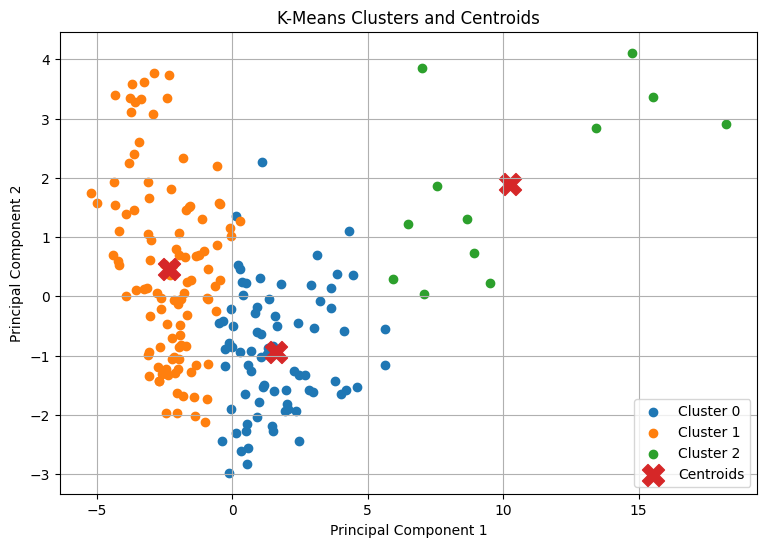


Mean feature values for each cluster:


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
Cluster,,,,,,,,,,,,,,,,,,,,,
0,135.524766,163.970026,94.936805,0.007045,0.007045,0.003713,0.003986,0.011139,0.039505,0.039505,...,0.031113,0.063435,0.027473,19.327727,0.568655,0.732230,-5.094898,0.253652,2.449171,0.253214
1,166.785019,215.052962,129.865689,0.003901,0.003901,0.001947,0.002093,0.005841,0.017342,0.017342,...,0.013879,0.027168,0.009222,24.803509,0.438806,0.707515,-6.341231,0.195621,2.264031,0.152846
2,163.330500,251.179417,133.950500,0.021417,0.021417,0.012707,0.011944,0.038123,0.076097,0.076097,...,0.069082,0.116602,0.146018,12.529833,0.576212,0.720921,-3.664981,0.325205,2.990218,0.381535


In [ ]:
# K-Means Clustering on Parkinson's Dataset

import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. Load Parkinson's Dataset
# --------------------------------------------------

parkinsons = fetch_ucirepo(id=174)

X = parkinsons.data.features
y = parkinsons.data.targets

# Remove name column because it is an identifier
if "name" in X.columns:
    X = X.drop(columns=["name"])

# Use only numerical features
X = X.select_dtypes(include="number")

print("Dataset shape:", X.shape)
display(X.head())

# --------------------------------------------------
# 2. Feature Scaling
# --------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFeatures after Standard Scaling:")
display(pd.DataFrame(X_scaled, columns=X.columns).head())

# --------------------------------------------------
# 3. Elbow Method
# --------------------------------------------------

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

# --------------------------------------------------
# 4. Apply K-Means
# --------------------------------------------------

# Set this according to the elbow point in the graph
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

# --------------------------------------------------
# 5. Assign Cluster Labels
# --------------------------------------------------

X_clustered = X.copy()

X_clustered["Cluster"] = cluster_labels

print("\nCluster labels:")
display(
    X_clustered[["Cluster"]].head(20)
)

print("\nNumber of data points in each cluster:")
print(
    X_clustered["Cluster"].value_counts().sort_index()
)

# --------------------------------------------------
# 6. Display Cluster Centroids
# --------------------------------------------------

centroids = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroids_df = pd.DataFrame(
    centroids,
    columns=X.columns
)

centroids_df.index.name = "Cluster"

print("\nCluster Centroids:")
display(centroids_df)

# --------------------------------------------------
# 7. PCA for Cluster Visualization
# --------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

centroids_pca = pca.transform(
    kmeans.cluster_centers_
)

# --------------------------------------------------
# 8. Visualize Clusters and Centroids
# --------------------------------------------------

plt.figure(figsize=(9, 6))

for cluster in range(optimal_k):

    points = X_pca[
        cluster_labels == cluster
    ]

    plt.scatter(
        points[:, 0],
        points[:, 1],
        label="Cluster " + str(cluster)
    )

# Plot centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters and Centroids")
plt.legend()
plt.grid(True)

plt.show()

# --------------------------------------------------
# 9. Analyze Cluster Characteristics
# --------------------------------------------------

cluster_means = X_clustered.groupby(
    "Cluster"
).mean()

print("\nMean feature values for each cluster:")
display(cluster_means)

## Lab 6: Hierarchical Clustering and Decision Tree Analysis

### 1. Hierarchical Clustering
We use the Ward linkage method to minimize variance within clusters and visualize the relationships using a dendrogram.

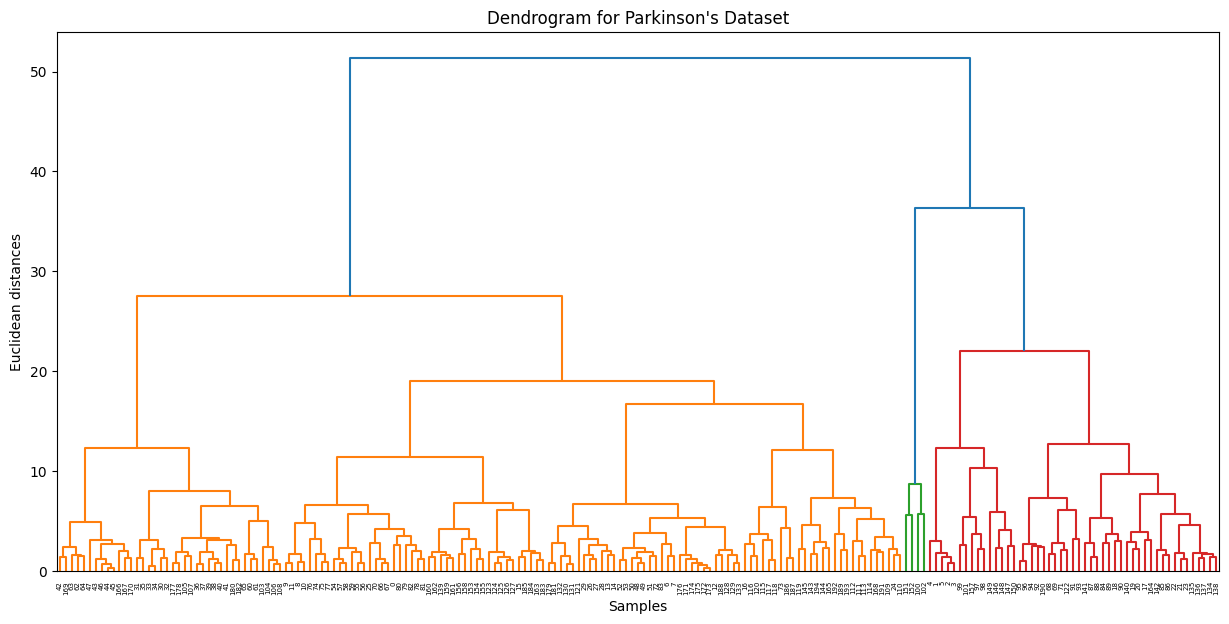

Hierarchical Cluster Assignments:
[0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1]


In [ ]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler

# 1. Load and Scale Dataset
parkinsons = fetch_ucirepo(id=174)
X = parkinsons.data.features
y = parkinsons.data.targets

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Visualize Dendrogram
plt.figure(figsize=(15, 7))
plt.title("Dendrogram for Parkinson's Dataset")
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.xlabel('Samples')
plt.ylabel('Euclidean distances')
plt.show()

# 3. Apply Agglomerative Clustering
# Note: 'affinity' was renamed to 'metric' in recent sklearn versions, and ward linkage requires euclidean metric
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

print("Hierarchical Cluster Assignments:")
print(y_hc[:20])

### 2. Decision Tree Classification (Information Gain)
We will train a decision tree using `entropy` as the splitting criterion to maximize Information Gain.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# Ensure y is flattened for compatibility
y_flat = y.values.ravel()


scaler_standard = StandardScaler()
X_scaled_standard = scaler_standard.fit_transform(X)

X_scaled_standard_df = pd.DataFrame(
    X_scaled_standard,
    columns=X.columns,
    index=X.index
)



X_scaled_standard_df = pd.DataFrame(
    X_scaled_standard,
    columns=X.columns,
    index=X.index
)


# Splitting the data using the standardized features from Lab 4
X_train, X_test, y_train, y_test = train_test_split(X_scaled_standard_df, y_flat, test_size=0.2, random_state=42)

# Initialize and train the model using Entropy (Information Gain)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

# Make predictions
y_pred_dt_ent = dt_entropy.predict(X_test)

print("Decision Tree (Entropy) Model Trained.")

Decision Tree (Entropy) Model Trained.


### 3. Visualizing the Decision Tree
This visualization shows the splitting conditions (features and thresholds), the entropy at each node, and the final class labels.

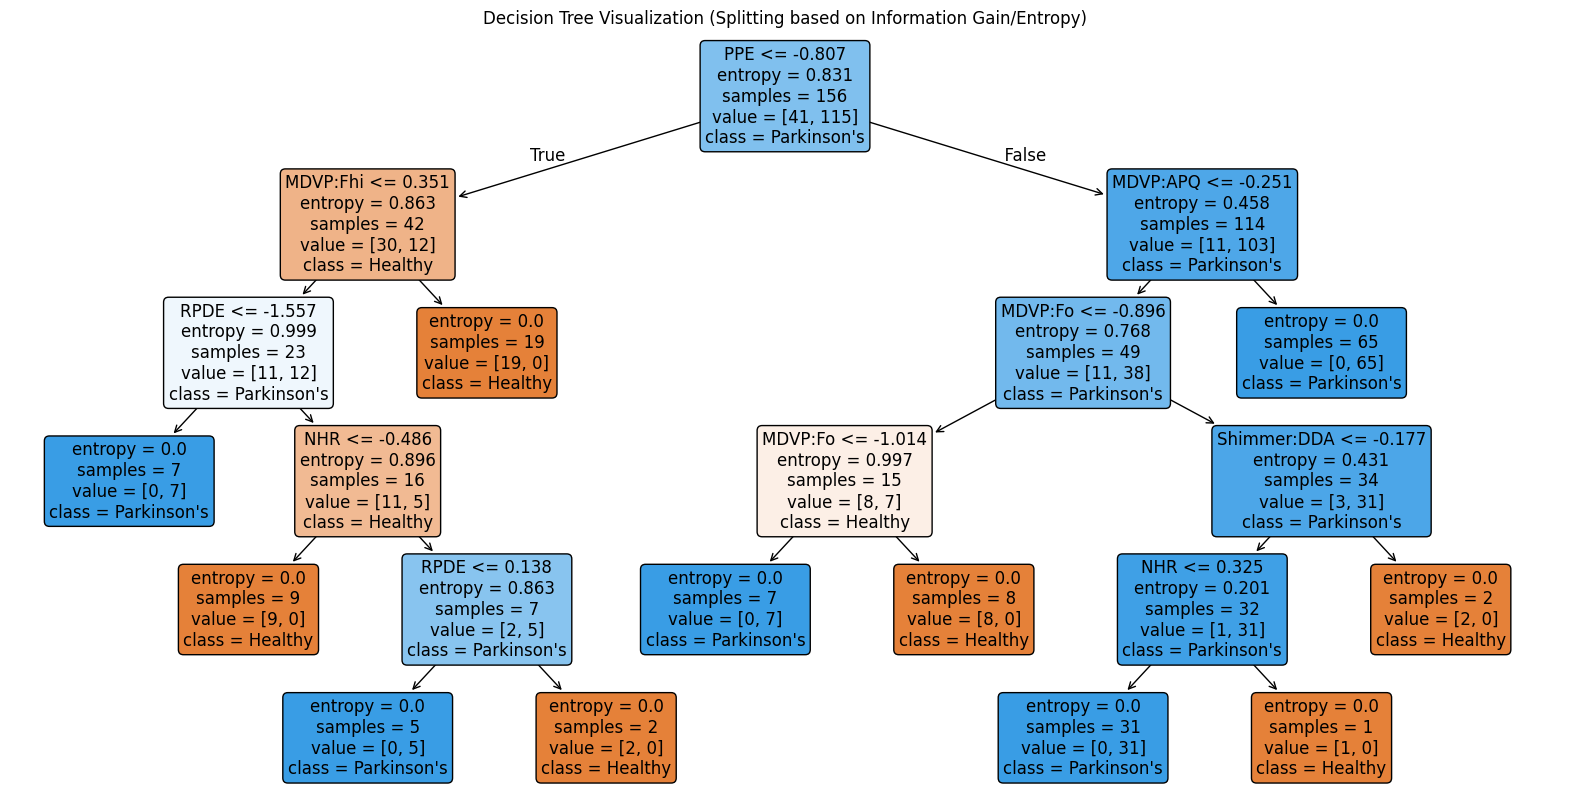

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_entropy,
          feature_names=X.columns,
          class_names=['Healthy', 'Parkinson\'s'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Decision Tree Visualization (Splitting based on Information Gain/Entropy)")
plt.show()

### 4. Model Evaluation
Evaluating the Decision Tree using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

In [ ]:
print("--- Decision Tree Performance Report ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_ent):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_ent))
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt_ent, target_names=['Healthy', 'Parkinson\'s']))

--- Decision Tree Performance Report ---
Accuracy: 0.9231

Confusion Matrix:
[[ 5  2]
 [ 1 31]]

Detailed Classification Report:
              precision    recall  f1-score   support

     Healthy       0.83      0.71      0.77         7
 Parkinson's       0.94      0.97      0.95        32

    accuracy                           0.92        39
   macro avg       0.89      0.84      0.86        39
weighted avg       0.92      0.92      0.92        39

